# Memory Data Quality Analysis — CPU vs Memory Forecasting Suitability

**Read-only research notebook.** Compare Alibaba **memory utilisation** against **CPU utilisation** to assess whether memory is suitable for long-term forecasting at the Module 1 resolution (15-minute), and to justify the research focus on CPU forecasting.

> **Scope:** Frozen preprocessing outputs (`df_resampled.parquet`, `train_df.parquet`, `val_df.parquet`, `selected_containers.npy`) plus a **read-only** scan of `container_usage.csv` for source-level completeness.  
> No retraining, no artefact writes to `experiments/`, no changes to forecasting models, production code, preprocessing, or AFMLF.  
> Complements `context_feature_feasibility` and `container_signal_analysis`.

## Completeness rule

On the frozen 15-minute grid, report **`cpu_util_percent` (before interpolation)** as the fair CPU completeness figure. Treat **`cpu_usage` / `cpu` (after interpolation)** as the modelling series only — do not present its 100% completeness as natural data quality.

## Research question

Is Alibaba memory utilisation of sufficient quality for the same long-term forecasting pipeline used for CPU, or does data quality alone justify selecting CPU as the Module 1 target?

## Kernel

Use the project environment (`tf_metal_env` / `FYP_Long_Term`), not a bare system Python — `statsmodels` and project `utils` are required.

## 1. Configuration and imports

In [15]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
except ImportError as exc:
    raise ImportError(
        "statsmodels is required. Select the project kernel (tf_metal_env / FYP_Long_Term), "
        "not the system Jupyter kernel."
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.append(os.path.abspath(".."))

from utils.tma.acf_pacf import acf_confidence_band, compute_acf

# ---------------------------------------------------------------------------
# Analysis parameters (aligned with Module 1)
# ---------------------------------------------------------------------------
SAMPLING_MINUTES = 15
DAY_LAG = 96
MAX_ACF_LAG = 192
LJUNG_BOX_LAGS = 20
ALPHA = 0.05
RAW_CHUNKSIZE = 1_000_000
EXAMPLE_CONTAINERS = ["c_11461", "c_10185", "c_12207"]  # illustrative series plots

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "data"
RESAMPLED_PATH = DATA_DIR / "df_resampled.parquet"
TRAIN_PATH = DATA_DIR / "train_df.parquet"
VAL_PATH = DATA_DIR / "val_df.parquet"
SELECTED_PATH = DATA_DIR / "selected_containers.npy"
RAW_PATH = DATA_DIR / "container_usage.csv"

COLOR_CPU = "#2CA02C"
COLOR_MEM = "#C44E52"
COLOR_ACF = "#8172B2"
COLOR_BAND = "#4C72B0"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print("Repository root:", REPO_ROOT)
print("Frozen inputs:")
for p in [RESAMPLED_PATH, TRAIN_PATH, VAL_PATH, SELECTED_PATH, RAW_PATH]:
    print(f"  {'OK' if p.exists() else 'MISSING'}: {p.relative_to(REPO_ROOT)}")

Repository root: /Users/lehaan/Desktop/FYP_Long_Term
Frozen inputs:
  OK: data/df_resampled.parquet
  OK: data/train_df.parquet
  OK: data/val_df.parquet
  OK: data/selected_containers.npy
  OK: data/container_usage.csv


## 2. Load frozen preprocessing outputs (read-only)

All cohort analysis below uses the **same frozen artefacts** as Hybrid / Global GRU experiments. No files are written.

In [16]:
selected = np.load(SELECTED_PATH, allow_pickle=True)
selected_ids = set(map(str, selected))

resample_cols = [
    "container_id", "time_stamp",
    "cpu_util_percent", "cpu_usage", "mem_util_percent",
]
df_res = pd.read_parquet(RESAMPLED_PATH, columns=resample_cols)
df_res["container_id"] = df_res["container_id"].astype(str)
df_sel = df_res[df_res["container_id"].isin(selected_ids)].copy()

train = pd.read_parquet(
    TRAIN_PATH,
    columns=["container_id", "time_stamp", "cpu_util_percent", "cpu_usage", "cpu", "mem_util_percent"],
)
val = pd.read_parquet(
    VAL_PATH,
    columns=["container_id", "time_stamp", "cpu_util_percent", "cpu_usage", "cpu", "mem_util_percent"],
)
train["container_id"] = train["container_id"].astype(str)
val["container_id"] = val["container_id"].astype(str)
train_sel = train[train["container_id"].isin(selected_ids)].copy()
val_sel = val[val["container_id"].isin(selected_ids)].copy()

print(f"Selected cohort size (npy): {len(selected_ids)}")
print(f"Resampled selected: {len(df_sel):,} rows | {df_sel['container_id'].nunique()} containers")
print(f"Train selected:     {len(train_sel):,} rows")
print(f"Val selected:       {len(val_sel):,} rows")
print(f"Timestamp range (resampled): {df_sel['time_stamp'].min()} → {df_sel['time_stamp'].max()}")
print(
    "Note: fair completeness comparisons use cpu_util_percent (before interpolation), "
    "not cpu_usage/cpu (after gap-fill)."
)

Selected cohort size (npy): 100
Resampled selected: 75,877 rows | 99 containers
Train selected:     60,658 rows
Val selected:       15,219 rows
Timestamp range (resampled): 1970-01-02 00:00:00 → 1970-01-09 23:45:00
Note: fair completeness comparisons use cpu_util_percent (before interpolation), not cpu_usage/cpu (after gap-fill).


## 3. Helper functions

In [17]:
def completeness_stats(series: pd.Series, name: str) -> dict:
    n = len(series)
    nn = int(series.notna().sum())
    valid = series.dropna().astype(float)
    return {
        "series": name,
        "n": n,
        "non_null": nn,
        "null": n - nn,
        "completeness_%": 100.0 * nn / n if n else np.nan,
        "missing_%": 100.0 * (n - nn) / n if n else np.nan,
        "nunique": int(valid.nunique()) if len(valid) else 0,
        "mean": float(valid.mean()) if len(valid) else np.nan,
        "std": float(valid.std(ddof=1)) if len(valid) > 1 else np.nan,
        "min": float(valid.min()) if len(valid) else np.nan,
        "max": float(valid.max()) if len(valid) else np.nan,
        "cv": float(valid.std(ddof=1) / valid.mean()) if len(valid) > 1 and valid.mean() != 0 else np.nan,
    }


def per_container_quality(frame: pd.DataFrame, cpu_col: str, mem_col: str) -> pd.DataFrame:
    rows = []
    for cid, g in frame.groupby("container_id", sort=False):
        n = len(g)
        cpu = g[cpu_col].astype(float)
        mem = g[mem_col].astype(float)
        rows.append({
            "container_id": cid,
            "n": n,
            "cpu_completeness": float(cpu.notna().mean()),
            "mem_completeness": float(mem.notna().mean()),
            "cpu_nunique": int(cpu.nunique(dropna=True)),
            "mem_nunique": int(mem.nunique(dropna=True)),
            "cpu_std": float(cpu.std(skipna=True)) if cpu.notna().sum() > 1 else np.nan,
            "mem_std": float(mem.std(skipna=True)) if mem.notna().sum() > 1 else np.nan,
            "cpu_mean": float(cpu.mean(skipna=True)) if cpu.notna().any() else np.nan,
            "mem_mean": float(mem.mean(skipna=True)) if mem.notna().any() else np.nan,
        })
    return pd.DataFrame(rows)


def temporal_metrics(values: np.ndarray, max_lag: int = MAX_ACF_LAG, lb_lags: int = LJUNG_BOX_LAGS) -> dict:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    out = {
        "n": int(len(x)),
        "acf_lag1": np.nan,
        "acf_lag_day": np.nan,
        "ljung_box_stat": np.nan,
        "ljung_box_pvalue": np.nan,
        "reject_white_noise": False,
    }
    if len(x) < max(lb_lags + 5, 30):
        return out
    lag_cap = min(max_lag, len(x) - 2)
    lags, acf_vals = compute_acf(x, lag_cap)
    out["acf_lag1"] = float(acf_vals[1]) if len(acf_vals) > 1 else np.nan
    day_idx = DAY_LAG if DAY_LAG <= lag_cap else None
    if day_idx is not None and day_idx < len(acf_vals):
        out["acf_lag_day"] = float(acf_vals[day_idx])
    lb = acorr_ljungbox(x, lags=[lb_lags], return_df=True)
    out["ljung_box_stat"] = float(lb["lb_stat"].iloc[0])
    out["ljung_box_pvalue"] = float(lb["lb_pvalue"].iloc[0])
    out["reject_white_noise"] = bool(out["ljung_box_pvalue"] < ALPHA)
    return out


def load_raw_selected(
    path: Path,
    ids: set[str],
    chunksize: int = RAW_CHUNKSIZE,
) -> pd.DataFrame:
    """Read-only chunked load of raw CPU/memory for the selected cohort."""
    usecols = ["container_id", "time_stamp", "cpu_util_percent", "mem_util_percent"]
    parts: list[pd.DataFrame] = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        m = chunk["container_id"].astype(str).isin(ids)
        if m.any():
            parts.append(chunk.loc[m].copy())
    if not parts:
        return pd.DataFrame(columns=usecols)
    out = pd.concat(parts, ignore_index=True)
    out["container_id"] = out["container_id"].astype(str)
    out = out.sort_values(["container_id", "time_stamp"]).reset_index(drop=True)
    return out


print("Helpers ready.")

Helpers ready.


## 4. Source-level completeness (raw Alibaba CSV)

Before judging the frozen 15-minute pipeline, check whether memory exists in the **source** trace for the selected Hybrid cohort.

In [18]:
raw_sel = load_raw_selected(RAW_PATH, selected_ids)
print(f"Raw selected rows: {len(raw_sel):,} | containers: {raw_sel['container_id'].nunique()}")

raw_summary = pd.DataFrame([
    completeness_stats(raw_sel["cpu_util_percent"], "raw_cpu_util_percent"),
    completeness_stats(raw_sel["mem_util_percent"], "raw_mem_util_percent"),
])
display(raw_summary.round(3))

raw_pc = per_container_quality(raw_sel, "cpu_util_percent", "mem_util_percent")
print("\nPer-container completeness (raw selected cohort)")
display(raw_pc[["cpu_completeness", "mem_completeness", "cpu_nunique", "mem_nunique", "cpu_std", "mem_std"]].describe().round(4))

Raw selected rows: 111,243 | containers: 100


,series,n,non_null,null,completeness_%,missing_%,nunique,mean,std,min,max,cv
0,raw_cpu_util_percent,111243,111243,0,100.0,0.0,87,9.181,10.668,0.0,94.0,1.162
1,raw_mem_util_percent,111243,111243,0,100.0,0.0,94,78.482,24.602,0.0,100.0,0.313



Per-container completeness (raw selected cohort)


,cpu_completeness,mem_completeness,cpu_nunique,mem_nunique,cpu_std,mem_std
count,100.0,100.0,100.0000,100.0000,100.0000,100.0000
mean,1.0,1.0,18.5200,19.8100,3.6866,4.6445
std,0.0,0.0,14.3854,14.0005,3.8651,4.4873
min,1.0,1.0,2.0000,3.0000,0.0301,0.3712
25%,1.0,1.0,7.0000,8.0000,0.9160,1.3746
50%,1.0,1.0,13.0000,16.0000,2.2490,3.5947
75%,1.0,1.0,27.2500,29.0000,5.5305,6.9803
max,1.0,1.0,70.0000,68.0000,17.8095,31.5801


## 5. Frozen 15-minute pipeline completeness

Module 1 trains and evaluates on **15-minute** series.

**Important distinction**

| Column | Stage | Use in this notebook |
|--------|--------|----------------------|
| `cpu_util_percent` | After 15-min resample, **before** gap-fill | **Primary** fairness comparison vs memory |
| `cpu_usage` / `cpu` | **After** CPU interpolation | Modelling series only — do **not** treat 100% as natural completeness |
| `mem_util_percent` | After resample; **never** interpolated | Memory completeness on the same grid |

The fair before-interpolation comparison is `cpu_util_percent` vs `mem_util_percent`.

In [19]:
layers = []

# Raw (source)
layers.append({**completeness_stats(raw_sel["cpu_util_percent"], "CPU"), "layer": "raw_selected", "resource": "CPU"})
layers.append({**completeness_stats(raw_sel["mem_util_percent"], "Memory"), "layer": "raw_selected", "resource": "Memory"})

# Resampled — BEFORE interpolation (fair comparison)
layers.append({
    **completeness_stats(df_sel["cpu_util_percent"], "CPU"),
    "layer": "resampled_15min_BEFORE_interp",
    "resource": "CPU (cpu_util_percent)",
})
layers.append({
    **completeness_stats(df_sel["mem_util_percent"], "Memory"),
    "layer": "resampled_15min_BEFORE_interp",
    "resource": "Memory (mem_util_percent)",
})

# Resampled — AFTER CPU interpolation only (not a fair natural-completeness claim)
layers.append({
    **completeness_stats(df_sel["cpu_usage"], "CPU"),
    "layer": "resampled_15min_AFTER_interp",
    "resource": "CPU (cpu_usage, interpolated)",
})

# Train / val — before vs after
layers.append({
    **completeness_stats(train_sel["cpu_util_percent"], "CPU"),
    "layer": "train_df_BEFORE_interp",
    "resource": "CPU (cpu_util_percent)",
})
layers.append({
    **completeness_stats(train_sel["mem_util_percent"], "Memory"),
    "layer": "train_df_BEFORE_interp",
    "resource": "Memory",
})
layers.append({
    **completeness_stats(train_sel["cpu"], "CPU"),
    "layer": "train_df_AFTER_interp",
    "resource": "CPU (cpu)",
})
layers.append({
    **completeness_stats(val_sel["cpu_util_percent"], "CPU"),
    "layer": "val_df_BEFORE_interp",
    "resource": "CPU (cpu_util_percent)",
})
layers.append({
    **completeness_stats(val_sel["mem_util_percent"], "Memory"),
    "layer": "val_df_BEFORE_interp",
    "resource": "Memory",
})
layers.append({
    **completeness_stats(val_sel["cpu"], "CPU"),
    "layer": "val_df_AFTER_interp",
    "resource": "CPU (cpu)",
})

completeness_table = pd.DataFrame(layers)[[
    "layer", "resource", "n", "non_null", "null", "completeness_%", "missing_%",
    "nunique", "mean", "std", "min", "max", "cv",
]].copy()

print("Table A — Completeness across pipeline layers")
print("Primary fair comparison rows are tagged BEFORE_interp.")
display(completeness_table.round(3))

before = completeness_table[completeness_table["layer"].str.contains("BEFORE_interp", regex=False)]
print("\nTable A1 — Before-interpolation completeness only (fair CPU vs Memory)")
display(before.round(3))

Table A — Completeness across pipeline layers
Primary fair comparison rows are tagged BEFORE_interp.


,layer,resource,n,non_null,null,completeness_%,missing_%,nunique,mean,std,min,max,cv
0,raw_selected,CPU,111243,111243,0,100.000,0.000,87,9.181,10.668,0.0,94.0,1.162
1,raw_selected,Memory,111243,111243,0,100.000,0.000,94,78.482,24.602,0.0,100.0,0.313
2,resampled_15min_BEFORE_interp,CPU (cpu_util_percent),75877,57075,18802,75.220,24.780,601,9.257,10.545,0.0,94.0,1.139
3,resampled_15min_BEFORE_interp,Memory (mem_util_percent),75877,1246,74631,1.642,98.358,86,78.758,24.305,8.0,100.0,0.309
4,resampled_15min_AFTER_interp,"CPU (cpu_usage, interpolated)",75877,75877,0,100.000,0.000,3244,9.291,10.532,0.0,94.0,1.134
5,train_df_BEFORE_interp,CPU (cpu_util_percent),60658,45243,15415,74.587,25.413,566,8.962,10.223,0.0,94.0,1.141
6,train_df_BEFORE_interp,Memory,60658,981,59677,1.617,98.383,84,78.855,24.319,8.0,100.0,0.308
7,train_df_AFTER_interp,CPU (cpu),60658,60658,0,100.000,0.000,3073,9.030,10.240,0.0,94.0,1.134
8,val_df_BEFORE_interp,CPU (cpu_util_percent),15219,11832,3387,77.745,22.255,413,10.385,11.623,0.0,92.0,1.119
9,val_df_BEFORE_interp,Memory,15219,265,14954,1.741,98.259,63,78.396,24.293,8.0,100.0,0.310



Table A1 — Before-interpolation completeness only (fair CPU vs Memory)


,layer,resource,n,non_null,null,completeness_%,missing_%,nunique,mean,std,min,max,cv
2,resampled_15min_BEFORE_interp,CPU (cpu_util_percent),75877,57075,18802,75.220,24.780,601,9.257,10.545,0.0,94.0,1.139
3,resampled_15min_BEFORE_interp,Memory (mem_util_percent),75877,1246,74631,1.642,98.358,86,78.758,24.305,8.0,100.0,0.309
5,train_df_BEFORE_interp,CPU (cpu_util_percent),60658,45243,15415,74.587,25.413,566,8.962,10.223,0.0,94.0,1.141
6,train_df_BEFORE_interp,Memory,60658,981,59677,1.617,98.383,84,78.855,24.319,8.0,100.0,0.308
8,val_df_BEFORE_interp,CPU (cpu_util_percent),15219,11832,3387,77.745,22.255,413,10.385,11.623,0.0,92.0,1.119
9,val_df_BEFORE_interp,Memory,15219,265,14954,1.741,98.259,63,78.396,24.293,8.0,100.0,0.310


Table B — Per-container completeness BEFORE interpolation (fair comparison)


,metric,"CPU (cpu_util_percent, before interp)",Memory (mem_util_percent)
0,mean completeness,0.7522,0.0164
1,median completeness,0.7536,0.0157
2,min completeness,0.7236,0.0065
3,max completeness,0.7995,0.0300
4,containers with completeness ≥ 50%,99.0000,0.0000
5,containers with completeness ≥ 90%,0.0000,0.0000
6,containers with any non-null,99.0000,99.0000



Table B1 — Same grid AFTER CPU interpolation (contrast only; memory unchanged)


,metric,"CPU (cpu_usage, after interp)",Memory (mem_util_percent)
0,mean completeness,1.0,0.0164
1,median completeness,1.0,0.0157
2,min completeness,1.0,0.0065
3,max completeness,1.0,0.0300
4,containers with completeness ≥ 50%,99.0,0.0000
5,containers with completeness ≥ 90%,99.0,0.0000
6,containers with any non-null,99.0,99.0000


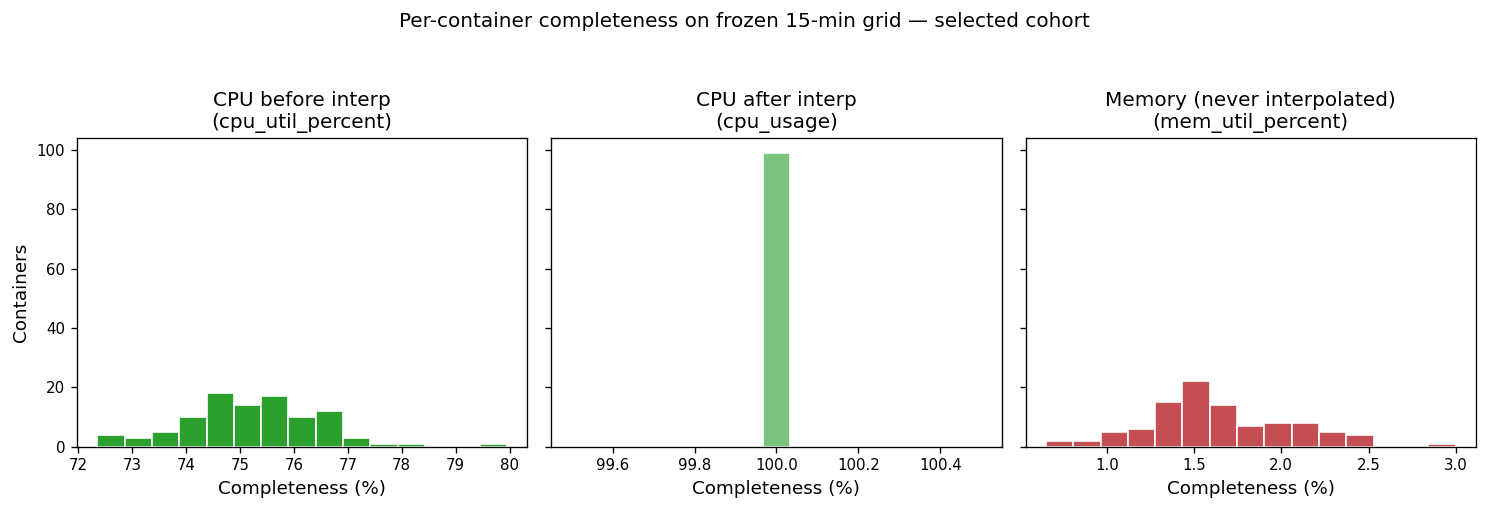

Before interp: mean CPU completeness = 75.2% | mean Memory = 1.6%
After interp:  mean CPU completeness = 100.0% (gap-filled; not natural completeness)


In [20]:
# Primary: BEFORE interpolation (cpu_util_percent vs mem)
pc_pre = per_container_quality(df_sel, "cpu_util_percent", "mem_util_percent")
# Secondary: AFTER CPU interpolation (for contrast only)
pc_post = per_container_quality(df_sel, "cpu_usage", "mem_util_percent")
# Keep pc_res as the before-interp table used by later scoring / decision cells
pc_res = pc_pre


def _completeness_summary(pc: pd.DataFrame, cpu_label: str) -> pd.DataFrame:
    return pd.DataFrame({
        "metric": [
            "mean completeness",
            "median completeness",
            "min completeness",
            "max completeness",
            "containers with completeness ≥ 50%",
            "containers with completeness ≥ 90%",
            "containers with any non-null",
        ],
        cpu_label: [
            pc["cpu_completeness"].mean(),
            pc["cpu_completeness"].median(),
            pc["cpu_completeness"].min(),
            pc["cpu_completeness"].max(),
            int((pc["cpu_completeness"] >= 0.5).sum()),
            int((pc["cpu_completeness"] >= 0.9).sum()),
            int((pc["cpu_completeness"] > 0).sum()),
        ],
        "Memory (mem_util_percent)": [
            pc["mem_completeness"].mean(),
            pc["mem_completeness"].median(),
            pc["mem_completeness"].min(),
            pc["mem_completeness"].max(),
            int((pc["mem_completeness"] >= 0.5).sum()),
            int((pc["mem_completeness"] >= 0.9).sum()),
            int((pc["mem_completeness"] > 0).sum()),
        ],
    })


print("Table B — Per-container completeness BEFORE interpolation (fair comparison)")
summary_b = _completeness_summary(pc_pre, "CPU (cpu_util_percent, before interp)")
display(summary_b.round(4))

print("\nTable B1 — Same grid AFTER CPU interpolation (contrast only; memory unchanged)")
summary_b1 = _completeness_summary(pc_post, "CPU (cpu_usage, after interp)")
display(summary_b1.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4), sharey=True)
axes[0].hist(pc_pre["cpu_completeness"] * 100, bins=15, color=COLOR_CPU, edgecolor="white")
axes[0].set_title("CPU before interp\n(cpu_util_percent)")
axes[0].set_xlabel("Completeness (%)")
axes[0].set_ylabel("Containers")

axes[1].hist(pc_post["cpu_completeness"] * 100, bins=15, color="#7BC47F", edgecolor="white")
axes[1].set_title("CPU after interp\n(cpu_usage)")
axes[1].set_xlabel("Completeness (%)")

axes[2].hist(pc_pre["mem_completeness"] * 100, bins=15, color=COLOR_MEM, edgecolor="white")
axes[2].set_title("Memory (never interpolated)\n(mem_util_percent)")
axes[2].set_xlabel("Completeness (%)")

fig.suptitle("Per-container completeness on frozen 15-min grid — selected cohort", y=1.05)
fig.tight_layout()
plt.show()

print(
    f"Before interp: mean CPU completeness = {100*pc_pre['cpu_completeness'].mean():.1f}% | "
    f"mean Memory = {100*pc_pre['mem_completeness'].mean():.1f}%"
)
print(
    f"After interp:  mean CPU completeness = {100*pc_post['cpu_completeness'].mean():.1f}% "
    f"(gap-filled; not natural completeness)"
)


## 6. Missingness pattern visualisation

Compare missingness **before CPU interpolation** (`cpu_util_percent` vs `mem_util_percent`). The after-interpolation CPU series is shown only as a contrast.


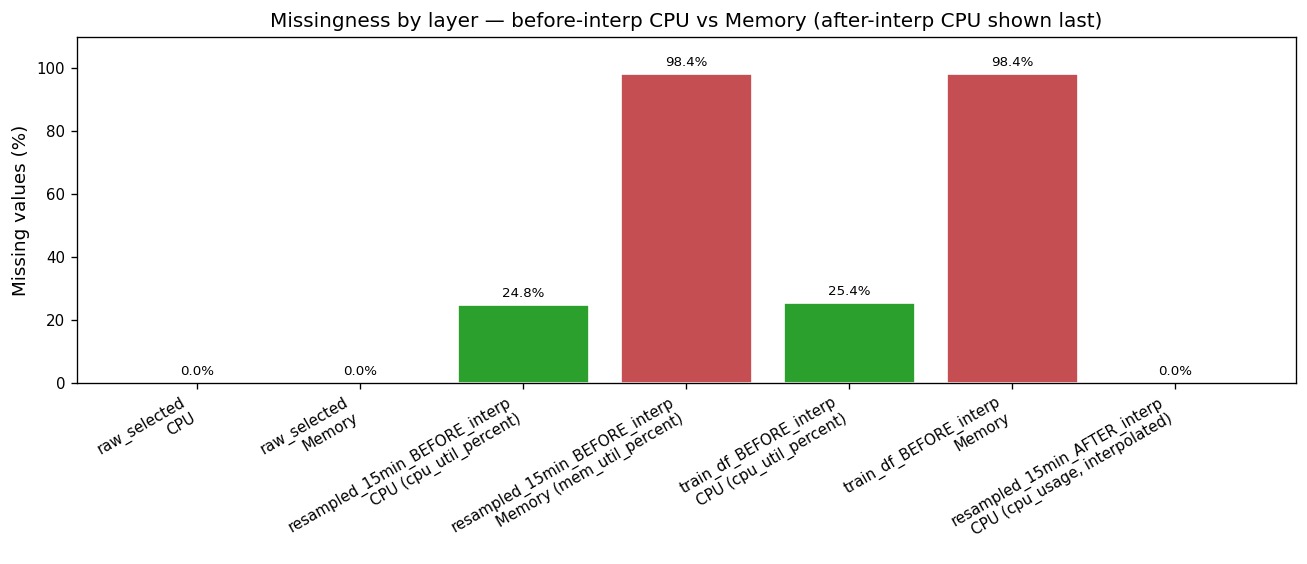

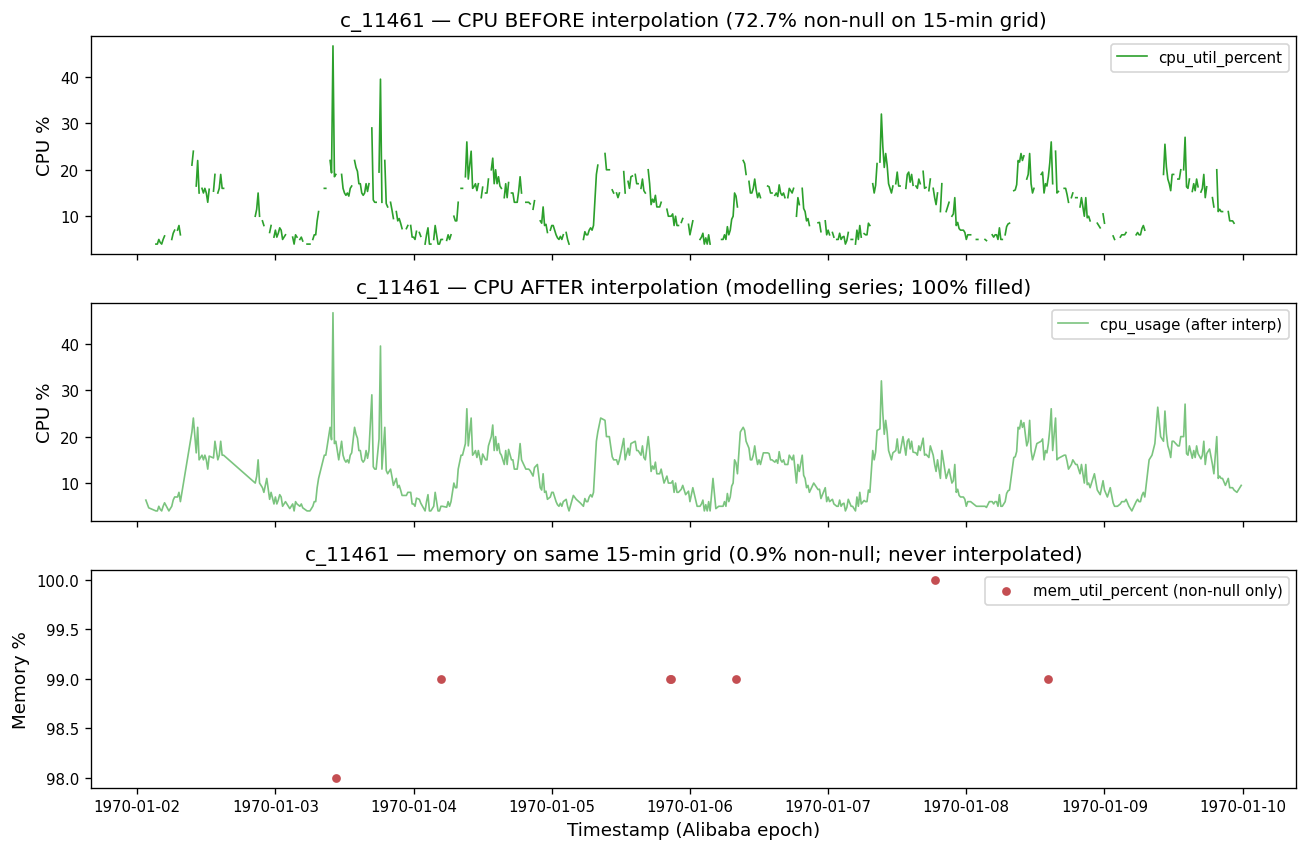

Example container: c_11461
Observed buckets — CPU before interp: 554 / 762 | Memory: 7 / 762


In [21]:
# Fair missingness view: raw + BEFORE interp (+ AFTER CPU only for contrast)
fair_layers = [
    "raw_selected",
    "resampled_15min_BEFORE_interp",
    "train_df_BEFORE_interp",
    "resampled_15min_AFTER_interp",
]
layer_plot = completeness_table[completeness_table["layer"].isin(fair_layers)].copy()
# Put AFTER_interp last so the jump to 0% missing for CPU is visible as contrast
layer_order = {k: i for i, k in enumerate(fair_layers)}
layer_plot["_ord"] = layer_plot["layer"].map(layer_order)
layer_plot = layer_plot.sort_values(["_ord", "resource"]).drop(columns="_ord")

fig, ax = plt.subplots(figsize=(11, 4.8))
labels = [f"{r.layer}\n{r.resource}" for r in layer_plot.itertuples()]
colors = [COLOR_CPU if "CPU" in r.resource else COLOR_MEM for r in layer_plot.itertuples()]
bars = ax.bar(range(len(layer_plot)), layer_plot["missing_%"].values, color=colors, edgecolor="white")
ax.set_xticks(range(len(layer_plot)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Missing values (%)")
ax.set_title("Missingness by layer — before-interp CPU vs Memory (after-interp CPU shown last)")
ax.set_ylim(0, 110)
for b, v in zip(bars, layer_plot["missing_%"].values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
plt.show()

# Example container: before-interp CPU gaps vs after-interp fill vs sparse memory
example_id = next((c for c in EXAMPLE_CONTAINERS if c in set(df_sel["container_id"])), df_sel["container_id"].iloc[0])
ex = df_sel[df_sel["container_id"] == example_id].sort_values("time_stamp")
cpu_obs = ex["cpu_util_percent"].notna()
mem_obs = ex["mem_util_percent"].notna()

fig, axes = plt.subplots(3, 1, figsize=(11, 7.2), sharex=True)

axes[0].plot(ex["time_stamp"], ex["cpu_util_percent"], color=COLOR_CPU, linewidth=1.0, label="cpu_util_percent")
axes[0].set_ylabel("CPU %")
axes[0].set_title(
    f"{example_id} — CPU BEFORE interpolation "
    f"({cpu_obs.mean()*100:.1f}% non-null on 15-min grid)"
)
axes[0].legend(loc="upper right")

axes[1].plot(ex["time_stamp"], ex["cpu_usage"], color="#7BC47F", linewidth=1.0, label="cpu_usage (after interp)")
axes[1].set_ylabel("CPU %")
axes[1].set_title(f"{example_id} — CPU AFTER interpolation (modelling series; 100% filled)")
axes[1].legend(loc="upper right")

axes[2].scatter(
    ex.loc[mem_obs, "time_stamp"],
    ex.loc[mem_obs, "mem_util_percent"],
    color=COLOR_MEM, s=18, label="mem_util_percent (non-null only)",
)
axes[2].set_ylabel("Memory %")
axes[2].set_xlabel("Timestamp (Alibaba epoch)")
axes[2].set_title(
    f"{example_id} — memory on same 15-min grid "
    f"({mem_obs.mean()*100:.1f}% non-null; never interpolated)"
)
axes[2].legend(loc="upper right")
fig.tight_layout()
plt.show()
print(f"Example container: {example_id}")
print(
    f"Observed buckets — CPU before interp: {cpu_obs.sum()} / {len(ex)} | "
    f"Memory: {mem_obs.sum()} / {len(ex)}"
)


## 7. Variance, unique values, and dynamic range

Even where memory exists at source, forecasting needs **non-degenerate variation**. Compare dispersion and uniqueness at raw and frozen layers.

Table C — Variance, uniqueness, and saturation


,layer,resource,nunique,mean,std,cv,min,max,n,share_at_floor_%,share_at_ceiling_%
0,raw_selected,CPU,87,9.181,10.668,1.162,0.0,94.0,111243,7.712,0.000
1,raw_selected,Memory,94,78.482,24.602,0.313,0.0,100.0,111243,0.001,11.487
2,resampled_15min,CPU (cpu_usage),3244,9.291,10.532,1.134,0.0,94.0,75877,6.862,0.000
3,resampled_15min,Memory (non-null only),86,78.758,24.305,0.309,8.0,100.0,1246,0.000,11.316


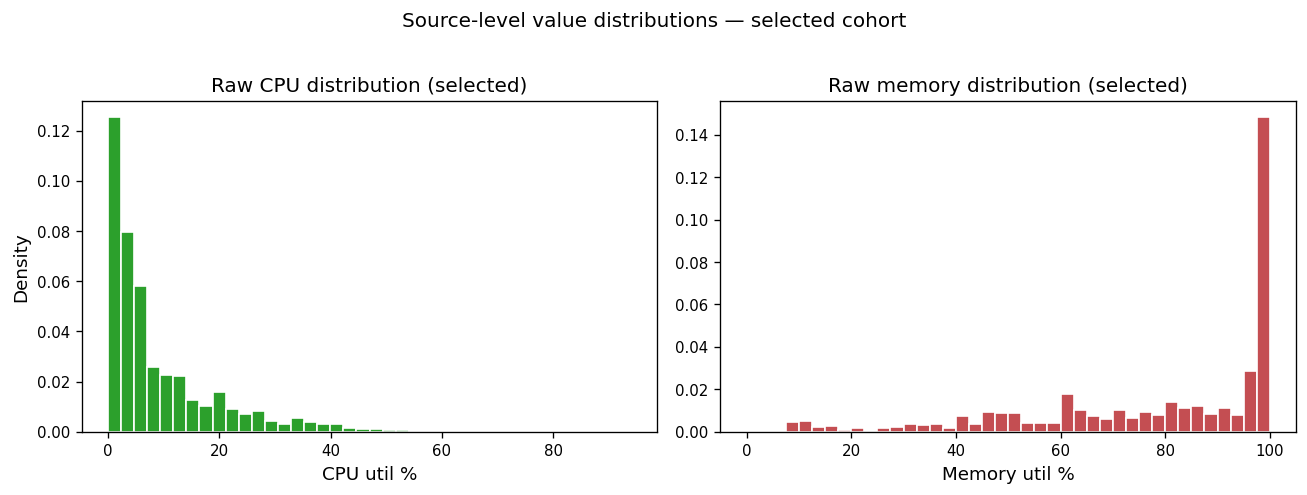

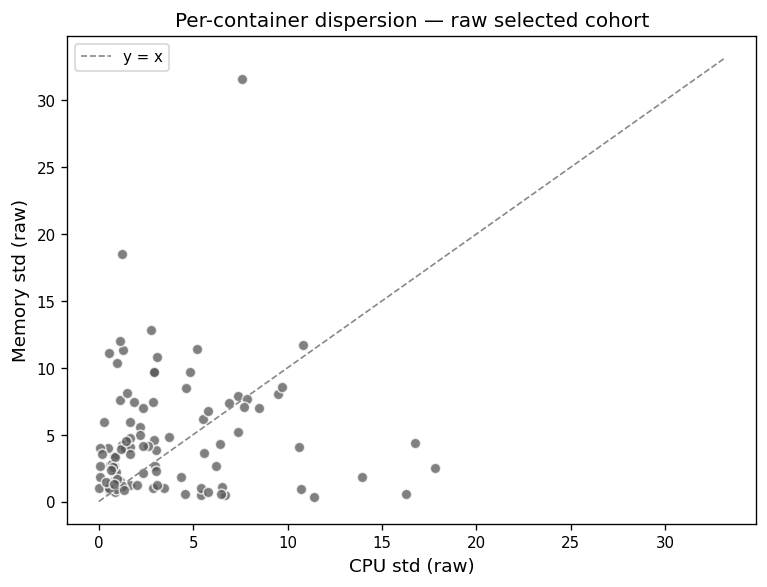

In [22]:
def saturation_share(series: pd.Series, lo: float = 0.0, hi: float = 100.0, tol: float = 0.5) -> dict:
    x = series.dropna().astype(float)
    if len(x) == 0:
        return {"n": 0, "share_at_floor_%": np.nan, "share_at_ceiling_%": np.nan}
    return {
        "n": int(len(x)),
        "share_at_floor_%": 100.0 * ((x <= lo + tol).mean()),
        "share_at_ceiling_%": 100.0 * ((x >= hi - tol).mean()),
    }


var_rows = [
    {
        "layer": "raw_selected",
        "resource": "CPU",
        **{k: completeness_stats(raw_sel["cpu_util_percent"], "CPU")[k] for k in ["nunique", "mean", "std", "cv", "min", "max"]},
        **saturation_share(raw_sel["cpu_util_percent"]),
    },
    {
        "layer": "raw_selected",
        "resource": "Memory",
        **{k: completeness_stats(raw_sel["mem_util_percent"], "Memory")[k] for k in ["nunique", "mean", "std", "cv", "min", "max"]},
        **saturation_share(raw_sel["mem_util_percent"]),
    },
    {
        "layer": "resampled_15min",
        "resource": "CPU (cpu_usage)",
        **{k: completeness_stats(df_sel["cpu_usage"], "CPU")[k] for k in ["nunique", "mean", "std", "cv", "min", "max"]},
        **saturation_share(df_sel["cpu_usage"]),
    },
    {
        "layer": "resampled_15min",
        "resource": "Memory (non-null only)",
        **{k: completeness_stats(df_sel["mem_util_percent"], "Memory")[k] for k in ["nunique", "mean", "std", "cv", "min", "max"]},
        **saturation_share(df_sel["mem_util_percent"]),
    },
]
variance_table = pd.DataFrame(var_rows)
print("Table C — Variance, uniqueness, and saturation")
display(variance_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(raw_sel["cpu_util_percent"].dropna(), bins=40, color=COLOR_CPU, edgecolor="white", density=True)
axes[0].set_title("Raw CPU distribution (selected)")
axes[0].set_xlabel("CPU util %")
axes[0].set_ylabel("Density")
axes[1].hist(raw_sel["mem_util_percent"].dropna(), bins=40, color=COLOR_MEM, edgecolor="white", density=True)
axes[1].set_title("Raw memory distribution (selected)")
axes[1].set_xlabel("Memory util %")
fig.suptitle("Source-level value distributions — selected cohort", y=1.02)
fig.tight_layout()
plt.show()

# Per-container std comparison (raw)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(raw_pc["cpu_std"], raw_pc["mem_std"], alpha=0.75, c="#555555", edgecolors="white", s=40)
lim = max(raw_pc["cpu_std"].max(), raw_pc["mem_std"].max()) * 1.05
ax.plot([0, lim], [0, lim], "--", color="#888888", linewidth=1, label="y = x")
ax.set_xlabel("CPU std (raw)")
ax.set_ylabel("Memory std (raw)")
ax.set_title("Per-container dispersion — raw selected cohort")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Temporal structure — ACF and Ljung–Box

Compare autocorrelation and white-noise rejection for CPU vs memory.

- **Raw selected cohort:** both series are complete → fair temporal comparison on ordered samples.
- **Frozen 15-min grid:** CPU has a continuous series; memory has too few points per container (~1–3%) for reliable long-lag ACF, which is itself evidence against forecasting suitability.

Table D — Temporal structure summary (raw selected cohort)


,metric,CPU,Memory
0,mean ACF lag-1,0.4302,0.8525
1,median ACF lag-1,0.3994,0.9670
2,mean |ACF lag-1|,0.4325,0.8527
3,mean ACF lag-96 (≈1 day @ 15-min; N/A if serie...,-0.0655,0.2256
4,Ljung–Box reject white noise @ lag 20 (count),78.0000,98.0000
5,Ljung–Box reject white noise @ lag 20 (%),78.0000,98.0000
6,containers evaluable (n ≥ threshold),100.0000,100.0000


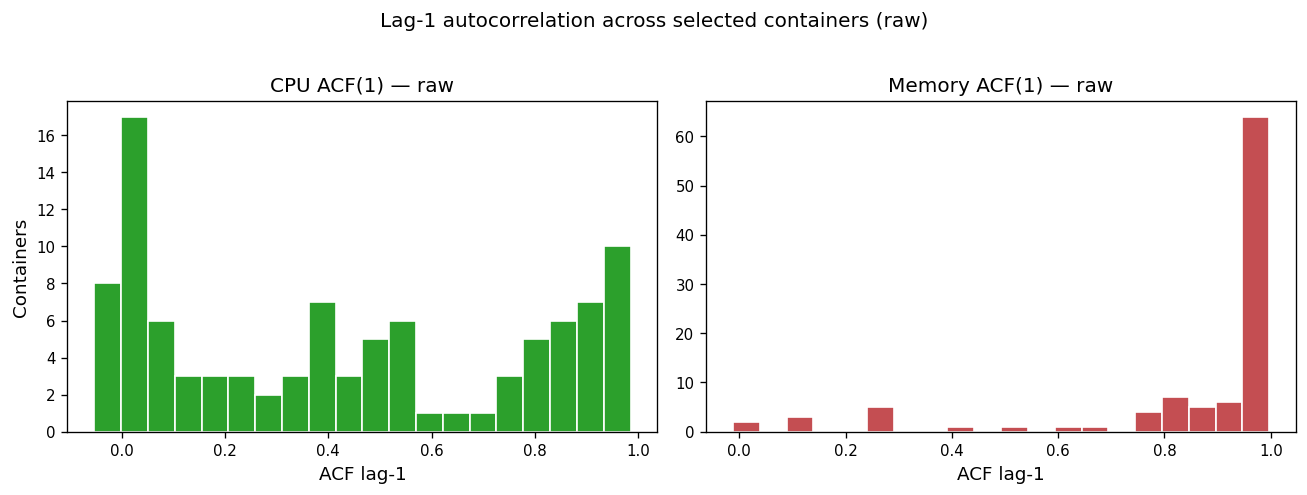

In [23]:
temporal_rows = []
for cid, g in raw_sel.groupby("container_id", sort=False):
    g = g.sort_values("time_stamp")
    cpu_m = temporal_metrics(g["cpu_util_percent"].to_numpy())
    mem_m = temporal_metrics(g["mem_util_percent"].to_numpy())
    temporal_rows.append({
        "container_id": cid,
        "cpu_n": cpu_m["n"],
        "mem_n": mem_m["n"],
        "cpu_acf_lag1": cpu_m["acf_lag1"],
        "mem_acf_lag1": mem_m["acf_lag1"],
        "cpu_acf_lag_day": cpu_m["acf_lag_day"],
        "mem_acf_lag_day": mem_m["acf_lag_day"],
        "cpu_lb_pvalue": cpu_m["ljung_box_pvalue"],
        "mem_lb_pvalue": mem_m["ljung_box_pvalue"],
        "cpu_reject_wn": cpu_m["reject_white_noise"],
        "mem_reject_wn": mem_m["reject_white_noise"],
    })

temporal_raw = pd.DataFrame(temporal_rows)

print("Table D — Temporal structure summary (raw selected cohort)")
temporal_summary = pd.DataFrame({
    "metric": [
        "mean ACF lag-1",
        "median ACF lag-1",
        "mean |ACF lag-1|",
        f"mean ACF lag-{DAY_LAG} (≈1 day @ 15-min; N/A if series shorter)",
        f"Ljung–Box reject white noise @ lag {LJUNG_BOX_LAGS} (count)",
        f"Ljung–Box reject white noise @ lag {LJUNG_BOX_LAGS} (%)",
        "containers evaluable (n ≥ threshold)",
    ],
    "CPU": [
        temporal_raw["cpu_acf_lag1"].mean(),
        temporal_raw["cpu_acf_lag1"].median(),
        temporal_raw["cpu_acf_lag1"].abs().mean(),
        temporal_raw["cpu_acf_lag_day"].mean(),
        int(temporal_raw["cpu_reject_wn"].sum()),
        100.0 * temporal_raw["cpu_reject_wn"].mean(),
        int(temporal_raw["cpu_acf_lag1"].notna().sum()),
    ],
    "Memory": [
        temporal_raw["mem_acf_lag1"].mean(),
        temporal_raw["mem_acf_lag1"].median(),
        temporal_raw["mem_acf_lag1"].abs().mean(),
        temporal_raw["mem_acf_lag_day"].mean(),
        int(temporal_raw["mem_reject_wn"].sum()),
        100.0 * temporal_raw["mem_reject_wn"].mean(),
        int(temporal_raw["mem_acf_lag1"].notna().sum()),
    ],
})
display(temporal_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(temporal_raw["cpu_acf_lag1"].dropna(), bins=20, color=COLOR_CPU, edgecolor="white")
axes[0].set_title("CPU ACF(1) — raw")
axes[0].set_xlabel("ACF lag-1")
axes[0].set_ylabel("Containers")
axes[1].hist(temporal_raw["mem_acf_lag1"].dropna(), bins=20, color=COLOR_MEM, edgecolor="white")
axes[1].set_title("Memory ACF(1) — raw")
axes[1].set_xlabel("ACF lag-1")
fig.suptitle("Lag-1 autocorrelation across selected containers (raw)", y=1.02)
fig.tight_layout()
plt.show()

Illustrative ACF plots (raw selected containers)


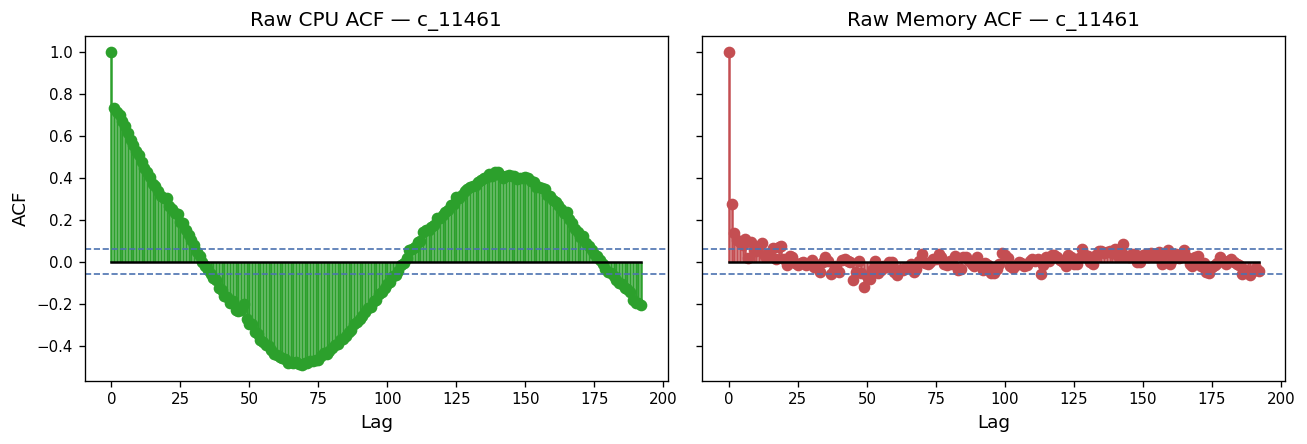

In [24]:
def plot_acf_pair(cid: str, frame: pd.DataFrame, cpu_col: str, mem_col: str, title_prefix: str) -> None:
    g = frame[frame["container_id"] == cid].sort_values("time_stamp")
    if g.empty:
        print(f"Skip {cid}: not found")
        return
    cpu = g[cpu_col].astype(float).to_numpy()
    mem = g[mem_col].astype(float).to_numpy()
    cpu = cpu[np.isfinite(cpu)]
    mem = mem[np.isfinite(mem)]
    if len(cpu) < 40 or len(mem) < 40:
        print(f"Skip {cid}: insufficient points (cpu={len(cpu)}, mem={len(mem)})")
        return

    lag_cap = min(MAX_ACF_LAG, len(cpu) - 2, len(mem) - 2)
    lags_c, acf_c = compute_acf(cpu, lag_cap)
    lags_m, acf_m = compute_acf(mem, lag_cap)
    band_c = acf_confidence_band(len(cpu), ALPHA)
    band_m = acf_confidence_band(len(mem), ALPHA)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
    axes[0].stem(lags_c, acf_c, linefmt=COLOR_CPU, markerfmt="o", basefmt="k-")
    axes[0].axhline(band_c, color=COLOR_BAND, linestyle="--", linewidth=1)
    axes[0].axhline(-band_c, color=COLOR_BAND, linestyle="--", linewidth=1)
    axes[0].set_title(f"{title_prefix} CPU ACF — {cid}")
    axes[0].set_xlabel("Lag")
    axes[0].set_ylabel("ACF")

    axes[1].stem(lags_m, acf_m, linefmt=COLOR_MEM, markerfmt="o", basefmt="k-")
    axes[1].axhline(band_m, color=COLOR_BAND, linestyle="--", linewidth=1)
    axes[1].axhline(-band_m, color=COLOR_BAND, linestyle="--", linewidth=1)
    axes[1].set_title(f"{title_prefix} Memory ACF — {cid}")
    axes[1].set_xlabel("Lag")
    fig.tight_layout()
    plt.show()


print("Illustrative ACF plots (raw selected containers)")
for cid in EXAMPLE_CONTAINERS:
    if cid in set(raw_sel["container_id"]):
        plot_acf_pair(cid, raw_sel, "cpu_util_percent", "mem_util_percent", "Raw")

In [25]:
# Frozen 15-min: CPU full series vs memory non-null subsequence (diagnostic only)
frozen_temporal = []
for cid, g in df_sel.groupby("container_id", sort=False):
    g = g.sort_values("time_stamp")
    cpu_m = temporal_metrics(g["cpu_usage"].to_numpy())
    mem_vals = g["mem_util_percent"].dropna().astype(float).to_numpy()
    mem_m = temporal_metrics(mem_vals)
    frozen_temporal.append({
        "container_id": cid,
        "cpu_n": cpu_m["n"],
        "mem_n_nonnull": mem_m["n"],
        "mem_completeness": float(g["mem_util_percent"].notna().mean()),
        "cpu_acf_lag1": cpu_m["acf_lag1"],
        "mem_acf_lag1": mem_m["acf_lag1"],
        "cpu_acf_lag_day": cpu_m["acf_lag_day"],
        "cpu_reject_wn": cpu_m["reject_white_noise"],
        "mem_reject_wn": mem_m["reject_white_noise"],
        "mem_evaluable": mem_m["n"] >= 30 and np.isfinite(mem_m["acf_lag1"]),
    })

frozen_t = pd.DataFrame(frozen_temporal)
print("Table E — Temporal evaluability on frozen 15-min selected cohort")
table_e = pd.DataFrame({
    "metric": [
        "mean series length",
        "mean completeness",
        "containers with evaluable ACF/Ljung–Box",
        "mean ACF lag-1 (evaluable)",
        f"Ljung–Box reject WN (evaluable count)",
        f"mean ACF lag-{DAY_LAG} (CPU modelling grid)",
    ],
    "CPU (cpu_usage)": [
        frozen_t["cpu_n"].mean(),
        1.0,
        int(frozen_t["cpu_acf_lag1"].notna().sum()),
        frozen_t["cpu_acf_lag1"].mean(),
        int(frozen_t["cpu_reject_wn"].sum()),
        frozen_t["cpu_acf_lag_day"].mean(),
    ],
    "Memory (non-null points only)": [
        frozen_t["mem_n_nonnull"].mean(),
        frozen_t["mem_completeness"].mean(),
        int(frozen_t["mem_evaluable"].sum()),
        frozen_t.loc[frozen_t["mem_evaluable"], "mem_acf_lag1"].mean(),
        int(frozen_t.loc[frozen_t["mem_evaluable"], "mem_reject_wn"].sum()),
        np.nan,
    ],
})
display(table_e.round(4))

print(
    "\nNote: Memory ACF on the frozen grid uses only surviving non-null points and "
    "does not represent a regular 15-minute series. Daily-lag ACF is therefore not reported for memory."
)

Table E — Temporal evaluability on frozen 15-min selected cohort


,metric,CPU (cpu_usage),Memory (non-null points only)
0,mean series length,766.4343,12.5859
1,mean completeness,1.0000,0.0164
2,containers with evaluable ACF/Ljung–Box,99.0000,0.0000
3,mean ACF lag-1 (evaluable),0.5823,NaN
4,Ljung–Box reject WN (evaluable count),95.0000,0.0000
5,mean ACF lag-96 (CPU modelling grid),0.3295,NaN



Note: Memory ACF on the frozen grid uses only surviving non-null points and does not represent a regular 15-minute series. Daily-lag ACF is therefore not reported for memory.


## 9. Overall signal-quality score (heuristic)

A transparent 0–100 score to summarise forecasting readiness for thesis discussion. Completeness uses the **before-interpolation** modelling grid (`cpu_util_percent` vs `mem_util_percent`), not the gap-filled `cpu_usage` series.

| Component | Weight | Rationale |
|-----------|--------|-----------|
| Completeness (frozen 15-min, before interp) | 40 | Unusable if mostly missing before gap-fill |
| Temporal structure (raw ACF/Ljung–Box) | 35 | Need non-white-noise dependence |
| Dispersion / non-degeneracy (raw) | 25 | Near-constant series is not forecastable |


Table F — Heuristic forecasting suitability scores (0–100)
Completeness component uses BEFORE-interpolation frozen-grid rates.


,cpu_score,mem_score,cpu_completeness_before_interp,mem_completeness_before_interp
count,99.000,99.000,99.000,99.000
mean,59.245,43.754,0.752,0.016
std,19.069,12.331,0.013,0.004
min,29.478,2.401,0.724,0.007
25%,43.903,38.849,0.745,0.014
50%,59.035,44.411,0.754,0.016
75%,77.629,53.108,0.760,0.020
max,90.613,60.783,0.799,0.030


Containers where CPU score > Memory score: 73 / 99
Mean CPU score: 59.2 | Mean Memory score: 43.8
Mean before-interp completeness used in score — CPU: 75.2% | Memory: 1.6%


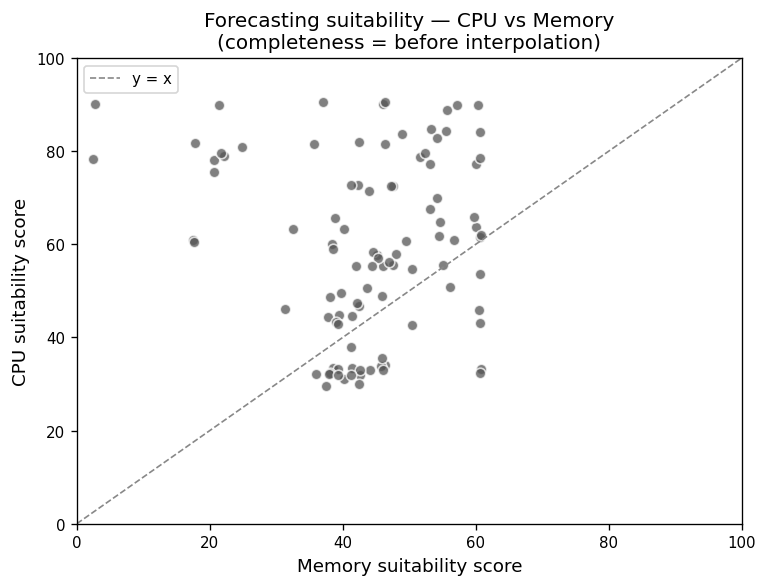

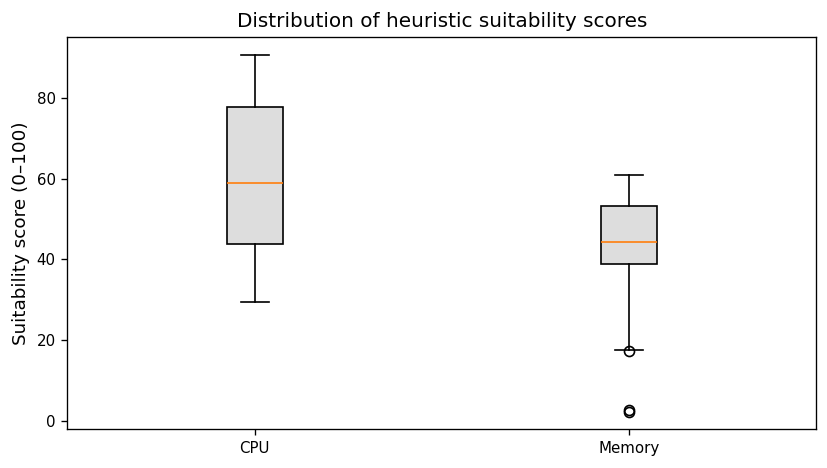

In [26]:
def clip01(x: float) -> float:
    return float(np.clip(x, 0.0, 1.0))


score_rows = []
raw_t_idx = temporal_raw.set_index("container_id")
pc_res_idx = pc_res.set_index("container_id")  # before-interp completeness
raw_pc_idx = raw_pc.set_index("container_id")

for cid in sorted(selected_ids & set(pc_res_idx.index) & set(raw_t_idx.index)):
    # Completeness on modelling grid BEFORE interpolation
    cpu_comp = clip01(float(pc_res_idx.loc[cid, "cpu_completeness"]))
    mem_comp = clip01(float(pc_res_idx.loc[cid, "mem_completeness"]))

    # Temporal: |ACF1| capped + WN rejection bonus
    cpu_acf = abs(float(raw_t_idx.loc[cid, "cpu_acf_lag1"])) if pd.notna(raw_t_idx.loc[cid, "cpu_acf_lag1"]) else 0.0
    mem_acf = abs(float(raw_t_idx.loc[cid, "mem_acf_lag1"])) if pd.notna(raw_t_idx.loc[cid, "mem_acf_lag1"]) else 0.0
    cpu_temp = clip01(0.7 * clip01(cpu_acf / 0.8) + 0.3 * float(raw_t_idx.loc[cid, "cpu_reject_wn"]))
    mem_temp = clip01(0.7 * clip01(mem_acf / 0.8) + 0.3 * float(raw_t_idx.loc[cid, "mem_reject_wn"]))

    # Dispersion: std relative to a soft reference (10% util)
    cpu_std = float(raw_pc_idx.loc[cid, "cpu_std"]) if cid in raw_pc_idx.index else 0.0
    mem_std = float(raw_pc_idx.loc[cid, "mem_std"]) if cid in raw_pc_idx.index else 0.0
    cpu_disp = clip01((0.0 if not np.isfinite(cpu_std) else cpu_std) / 10.0)
    mem_disp = clip01((0.0 if not np.isfinite(mem_std) else mem_std) / 10.0)

    cpu_score = 100.0 * (0.40 * cpu_comp + 0.35 * cpu_temp + 0.25 * cpu_disp)
    mem_score = 100.0 * (0.40 * mem_comp + 0.35 * mem_temp + 0.25 * mem_disp)

    score_rows.append({
        "container_id": cid,
        "cpu_score": cpu_score,
        "mem_score": mem_score,
        "cpu_completeness_before_interp": cpu_comp,
        "mem_completeness_before_interp": mem_comp,
        "cpu_acf_lag1_raw": cpu_acf,
        "mem_acf_lag1_raw": mem_acf,
    })

scores = pd.DataFrame(score_rows)
print("Table F — Heuristic forecasting suitability scores (0–100)")
print("Completeness component uses BEFORE-interpolation frozen-grid rates.")
display(scores[["cpu_score", "mem_score", "cpu_completeness_before_interp", "mem_completeness_before_interp"]].describe().round(3))
print(
    f"Containers where CPU score > Memory score: "
    f"{int((scores['cpu_score'] > scores['mem_score']).sum())} / {len(scores)}"
)
print(f"Mean CPU score: {scores['cpu_score'].mean():.1f} | Mean Memory score: {scores['mem_score'].mean():.1f}")
print(
    f"Mean before-interp completeness used in score — "
    f"CPU: {100*scores['cpu_completeness_before_interp'].mean():.1f}% | "
    f"Memory: {100*scores['mem_completeness_before_interp'].mean():.1f}%"
)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(scores["mem_score"], scores["cpu_score"], alpha=0.75, c="#555555", edgecolors="white", s=40)
ax.plot([0, 100], [0, 100], "--", color="#888888", linewidth=1, label="y = x")
ax.set_xlabel("Memory suitability score")
ax.set_ylabel("CPU suitability score")
ax.set_title("Forecasting suitability — CPU vs Memory\n(completeness = before interpolation)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    [scores["cpu_score"], scores["mem_score"]],
    tick_labels=["CPU", "Memory"],
    patch_artist=True,
    boxprops=dict(facecolor="#DDDDDD"),
)
ax.set_ylabel("Suitability score (0–100)")
ax.set_title("Distribution of heuristic suitability scores")
fig.tight_layout()
plt.show()


## 10. Decision summary for the thesis

Compile a single comparison table suitable for justifying **CPU-only** long-term forecasting in Module 1.

In [27]:
cpu_miss_before = float(completeness_stats(df_sel["cpu_util_percent"], "CPU")["missing_%"])
cpu_miss_after = float(completeness_stats(df_sel["cpu_usage"], "CPU")["missing_%"])
mem_miss_frozen = float(completeness_stats(df_sel["mem_util_percent"], "Memory")["missing_%"])
cpu_miss_raw = float(completeness_stats(raw_sel["cpu_util_percent"], "CPU")["missing_%"])
mem_miss_raw = float(completeness_stats(raw_sel["mem_util_percent"], "Memory")["missing_%"])

decision = pd.DataFrame([
    {
        "criterion": "Source completeness (raw selected)",
        "CPU": f"{100 - cpu_miss_raw:.1f}% non-null",
        "Memory": f"{100 - mem_miss_raw:.1f}% non-null",
        "Favours": "Tie / both available",
    },
    {
        "criterion": "15-min grid completeness BEFORE interpolation",
        "CPU": f"{100 - cpu_miss_before:.1f}% non-null (cpu_util_percent)",
        "Memory": f"{100 - mem_miss_frozen:.1f}% non-null (mem_util_percent)",
        "Favours": "CPU",
    },
    {
        "criterion": "15-min grid completeness AFTER CPU interpolation",
        "CPU": f"{100 - cpu_miss_after:.1f}% non-null (cpu_usage / cpu)",
        "Memory": f"{100 - mem_miss_frozen:.1f}% non-null (unchanged; never interpolated)",
        "Favours": "CPU (pipeline fills CPU only)",
    },
    {
        "criterion": "Containers with ≥50% completeness BEFORE interpolation",
        "CPU": str(int((pc_pre["cpu_completeness"] >= 0.5).sum())),
        "Memory": str(int((pc_pre["mem_completeness"] >= 0.5).sum())),
        "Favours": "CPU",
    },
    {
        "criterion": "Unique values on frozen selected grid (observed)",
        "CPU": f"{int(df_sel['cpu_util_percent'].nunique(dropna=True))} before interp; {int(df_sel['cpu_usage'].nunique(dropna=True))} after",
        "Memory": str(int(df_sel["mem_util_percent"].nunique(dropna=True))),
        "Favours": "CPU",
    },
    {
        "criterion": "Mean |ACF lag-1| (raw selected)",
        "CPU": f"{temporal_raw['cpu_acf_lag1'].abs().mean():.3f}",
        "Memory": f"{temporal_raw['mem_acf_lag1'].abs().mean():.3f}",
        "Favours": "See discussion (both may show dependence)",
    },
    {
        "criterion": f"Ljung–Box WN rejection rate @ lag {LJUNG_BOX_LAGS} (raw)",
        "CPU": f"{100 * temporal_raw['cpu_reject_wn'].mean():.1f}%",
        "Memory": f"{100 * temporal_raw['mem_reject_wn'].mean():.1f}%",
        "Favours": "See discussion",
    },
    {
        "criterion": "Regular 15-min series usable for Hybrid/Global pipeline",
        "CPU": f"Yes — ~{100 - cpu_miss_before:.0f}% observed before fill; continuous after frozen interpolation",
        "Memory": "No — ~98% missing before/after; no gap-fill in pipeline",
        "Favours": "CPU",
    },
    {
        "criterion": "Mean heuristic suitability score (before-interp completeness)",
        "CPU": f"{scores['cpu_score'].mean():.1f}",
        "Memory": f"{scores['mem_score'].mean():.1f}",
        "Favours": "CPU",
    },
])

print("Table G — Thesis decision matrix")
display(decision)

print("\n" + "=" * 72)
print("KEY FINDING")
print("=" * 72)
print(
    "At the Alibaba source level, both CPU and memory utilisation are essentially "
    "complete for the selected cohort. On the frozen Module 1 15-minute grid "
    f"BEFORE interpolation, CPU (cpu_util_percent) is ~{100 - cpu_miss_before:.1f}% "
    f"complete while memory is only ~{100 - mem_miss_frozen:.1f}% complete "
    f"(~{mem_miss_frozen:.1f}% missing). CPU interpolation then produces a fully "
    f"populated modelling series (cpu_usage/cpu at {100 - cpu_miss_after:.1f}%); "
    "memory is never gap-filled. No container reaches 50% memory completeness on "
    "the modelling grid. Therefore memory is not suitable for the same long-term "
    "forecasting setup, and selecting CPU as the Module 1 target is justified by "
    "pre-interpolation data quality — not by claiming CPU was naturally 100% complete."
)
print("=" * 72)


Table G — Thesis decision matrix


,criterion,CPU,Memory,Favours
0,Source completeness (raw selected),100.0% non-null,100.0% non-null,Tie / both available
1,15-min grid completeness BEFORE interpolation,75.2% non-null (cpu_util_percent),1.6% non-null (mem_util_percent),CPU
2,15-min grid completeness AFTER CPU interpolation,100.0% non-null (cpu_usage / cpu),1.6% non-null (unchanged; never interpolated),CPU (pipeline fills CPU only)
3,Containers with ≥50% completeness BEFORE inter...,99,0,CPU
4,Unique values on frozen selected grid (observed),601 before interp; 3244 after,86,CPU
5,Mean |ACF lag-1| (raw selected),0.432,0.853,See discussion (both may show dependence)
6,Ljung–Box WN rejection rate @ lag 20 (raw),78.0%,98.0%,See discussion
7,Regular 15-min series usable for Hybrid/Global...,Yes — ~75% observed before fill; continuous af...,No — ~98% missing before/after; no gap-fill in...,CPU
8,Mean heuristic suitability score (before-inter...,59.2,43.8,CPU



KEY FINDING
At the Alibaba source level, both CPU and memory utilisation are essentially complete for the selected cohort. On the frozen Module 1 15-minute grid BEFORE interpolation, CPU (cpu_util_percent) is ~75.2% complete while memory is only ~1.6% complete (~98.4% missing). CPU interpolation then produces a fully populated modelling series (cpu_usage/cpu at 100.0%); memory is never gap-filled. No container reaches 50% memory completeness on the modelling grid. Therefore memory is not suitable for the same long-term forecasting setup, and selecting CPU as the Module 1 target is justified by pre-interpolation data quality — not by claiming CPU was naturally 100% complete.


## 11. Conclusion

### What the evidence shows

1. **Source completeness is not the blocker.** For the selected Hybrid cohort, raw `cpu_util_percent` and `mem_util_percent` are both present.
2. **Fair comparison is before interpolation.** On the frozen 15-minute grid, `cpu_util_percent` is about **75%** complete (~25% missing buckets). Memory is about **1.6%** complete (~98% missing). The **100%** figure for `cpu_usage` / `cpu` is **after** CPU gap-fill only.
3. **The research pipeline is 15-minute and CPU-centric.** Frozen artefacts retain a continuous CPU modelling series after interpolation; `mem_util_percent` is never interpolated and remains unusable at this resolution.
4. **Memory cannot support the same long-horizon protocol.** Hybrid and Global GRU require regular multi-day histories. Sparse memory points do not form a usable regular series.
5. **Raw temporal structure does not overturn the decision.** Even if raw memory shows autocorrelation, forecasting suitability for *this* project is gated by before-interpolation modelling-grid completeness.
6. **Heuristic scores favour CPU** when completeness is measured before interpolation (~75% vs ~1.6%), which is the scientifically honest comparison.

### Thesis justification (suggested wording)

> Although memory utilisation is recorded in the Alibaba container usage trace, after resampling to the Module 1 15-minute grid it is missing for approximately 98% of timesteps in the selected cohort. By contrast, CPU utilisation remains about 75% complete before gap-fill and is then interpolated to a continuous modelling series. Memory is never gap-filled and therefore does not provide a regular long-term series compatible with the Hybrid Prophet+GRU and Global GRU evaluation protocol. For this reason, Module 1 focuses on long-term **CPU** forecasting.

### Non-goals of this notebook

- Does **not** retrain models or invent a memory forecaster.
- Does **not** modify preprocessing to impute memory.
- Does **not** claim CPU was naturally 100% complete on the 15-minute grid — only that it is sufficiently observed to support interpolation, whereas memory is not.
- Does **not** claim memory is globally useless — only that it is unsuitable for *this* frozen long-term forecasting setup.
